# CatBoost survival model 

In [ ]:
import json
import os
import random
import sys
import warnings
from getpass import getpass
from itertools import product
from pathlib import Path
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import snowflake.connector
from catboost import CatBoostRegressor
from joblib import Parallel, delayed
from scipy import stats
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sksurv.metrics import integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
from snowflake.ml.model import custom_model


warnings.filterwarnings("ignore")
set_config(display="diagram")

# --- configuration -------------------------------------------------------
SNAPSHOT_DATE = "2026_08_28"  # the date of snapshot tables to use
N_CV_FOLDS = 5  # number of cross-validation folds for model training
HORIZON = 365.0  # horizon at which PFS probability is evaluated (in days)

SPLIT_RANDOM_SEED = 63990 
MODEL_RANDOM_SEED = 420

boot_rng = np.random.default_rng(7391)  # bootstrap rng, fixed for reproducibility

ARTIFACT_DIR = REPO_ROOT / "analyses" / "Catboost__unrefactor" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_PATH = ARTIFACT_DIR / f"baseline_hazard_{SNAPSHOT_DATE}.json"

# --- search settings -----------------------------------------------------
THREADS_PER_FIT = 4  # CatBoost threads per fit; keep small to avoid oversubscription
N_JOBS = max(1, (os.cpu_count() or 1) // THREADS_PER_FIT)  # outer parallel workers

print(f"Repo root: {REPO_ROOT}")
print(f"Parallel: {N_JOBS} workers * {THREADS_PER_FIT} threads")


### The one and only Snowflake query

The four staged notebooks each re-pulled the snapshot and joined it back to the
persisted split table. Here a single pull retrieves everything: features,
outcomes, and the published benchmark scores needed in section 5. The split
table join is gone — the split is derived in memory in section 2.


In [ ]:
mydat_l.tail(2)


In [3]:
mydat_l["dbp_target"] = np.where(
    mydat_l["pfs_event_type"]=="death_before_progression",
    mydat_l["pfs_days"].astype(float),
    -mydat_l["pfs_days"].astype(float),
)

# dbp_target_qbin: 14 quantile bins over dbp_target < 0, plus a single bin for dbp_target >= 0
neg_edges = pd.qcut(
    mydat_l.loc[mydat_l["dbp_target"] < 0, "dbp_target"],
    q=14,
    retbins=True,
    duplicates="drop",
)[1]

# open the lower tail, close the negative range at 0, and add one bin for >= 0
qbin_edges = np.concatenate(([-np.inf], neg_edges[1:-1], [0.0, np.inf]))

mydat_l["dbp_target_qbin"] = pd.cut(mydat_l["dbp_target"], bins=qbin_edges, right=False)

mydat_l["dbp_target_qbin"].value_counts(dropna=False).sort_index()

dbp_target_qbin
[-inf, -1111.143)        47
[-1111.143, -806.429)    46
[-806.429, -713.143)     46
[-713.143, -598.571)     47
[-598.571, -513.857)     46
[-513.857, -431.286)     46
[-431.286, -380.0)       44
[-380.0, -338.714)       49
[-338.714, -276.429)     46
[-276.429, -221.429)     46
[-221.429, -175.571)     47
[-175.571, -112.571)     46
[-112.571, -77.286)      46
[-77.286, 0.0)           47
[0.0, inf)               37
Name: count, dtype: int64

### Missingness check (raw pull)


In [5]:
# cox_target: signed survival time (CatBoost/XGBoost Cox convention)
#   > 0  -> event observed at pfs_days
#   < 0  -> censored at pfs_days
mydat_l["cox_target"] = np.where(
    mydat_l["pfs_event_flag"].astype(bool),
    mydat_l["pfs_days"].astype(float),
    -mydat_l["pfs_days"].astype(float),
)

mydat_l["cox_target_qbin"] = pd.qcut(mydat_l["cox_target"], q=14, duplicates="drop")

In [6]:
mydat_l["cox_target_qbin"].value_counts()

cox_target_qbin
(-489.214, -387.0]       50
(136.786, 254.0]         50
(254.0, 343.0]           50
(-659.429, -489.214]     49
(-971.429, -659.429]     49
(-1920.001, -971.429]    49
(59.857, 136.786]        49
(-271.429, -152.714]     49
(-57.0, 59.857]          49
(-152.714, -57.0]        49
(706.857, 2011.0]        49
(-387.0, -271.429]       48
(343.0, 500.0]           48
(500.0, 706.857]         48
Name: count, dtype: int64

In [ ]:
ax = mydat_l["cox_target"].hist(bins=48)

qbin_edges = mydat_l["cox_target_qbin"].cat.categories
cut_points = [*(iv.left for iv in qbin_edges), qbin_edges[-1].right]
for edge in cut_points:
    ax.axvline(edge, color="crimson", linestyle="--", linewidth=0.8)

ax.set_xlabel("cox_target (signed PFS days)")
ax.set_title(f"cox_target with {len(qbin_edges)} quantile bin boundaries")
ax

## 2. Train/test split (stratified)

Stratify by product + era + event flag so all three are balanced across train and
test. In the staged pipeline these assignments were written to
`MODEL_SPLIT_<SNAPSHOT_DATE>` and re-read by every downstream notebook.
Here `split_df` stays in memory and is merged straight onto `mydat_l`, so the
`split` / `cv_fold` columns are available exactly as the downstream code expects.


In [9]:
stratification_preprocessor = Pipeline(
    steps=[
        (
            "recode_product",
            FunctionTransformer(collapse_to_trial, feature_names_out="one-to-one"),
        ),
        (
            "impute_product",
            ProductImputer(
                product_col="product_received", cart_date_col="cart_admin_dt"
            ),
        ),
        (
            "add_era",
            EraTransformer(cart_date_col="cart_admin_dt"),
        ),
        (
            "add_pfs_days_bin",  # bin pfs_days into equal-width bins
            PfsDaysBinTransformer(pfs_col="pfs_days", n_bins=8),
        ),
    ]
)

mydat_stratification = stratification_preprocessor.fit_transform(mydat_l.copy())

train_indices, test_indices = train_test_split(
    np.arange(len(mydat_stratification)),
    test_size=0.3,
    stratify=mydat_stratification[["era", "product_received", "pfs_event_flag"]],
    random_state=SPLIT_RANDOM_SEED,
)

X_y_train_all = mydat_l.iloc[train_indices].copy()
X_y_test = mydat_l.iloc[test_indices].copy()

X_y_train_all.shape, X_y_test.shape


((480, 203), (206, 203))

### Check balance


In [ ]:
balance_checks = {}
for col in ["era", "product_received", "pfs_event_flag", "cox_target_qbin", "dbp_target_qbin"]:
    balance_checks[col] = pd.concat(
        [
            mydat_stratification.loc[train_indices, col].value_counts(normalize=True),
            mydat_stratification.loc[test_indices, col].value_counts(normalize=True),
        ],
        axis=1,
        keys=["train", "test"],
    )

pd.concat(balance_checks, names=["variable", "level"]).round(3)


### Cross-validation folds on the training rows

Folds are assigned on the training rows only, stratified on the same
era + product + event combination. `split_df` is then merged onto `mydat_l` to
produce `mydat` — the equivalent of what the staged notebooks got back by joining
the persisted split table.


In [ ]:
split_df = mydat_stratification[["mrn", "cart_admin_dt"]].copy()
split_df["split"] = "test"
split_df.loc[train_indices, "split"] = "train"

split_df["cv_fold"] = pd.array([None] * len(split_df), dtype="Int64")

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SPLIT_RANDOM_SEED)
train_strat_df = mydat_stratification[["era", "product_received", "pfs_event_flag", "cox_target_qbin"]].iloc[train_indices]
train_stratify = (
    train_strat_df["era"].astype(str)
    + "_"
    + train_strat_df["product_received"].astype(str)
    + "_"
    + train_strat_df["pfs_event_flag"].astype(str)
    + "_"
    + train_strat_df["cox_target_qbin"].astype(str)
)
for fold, (_, fold_idx) in enumerate(cv.split(train_stratify, train_stratify)):
    split_df.iloc[train_indices[fold_idx], split_df.columns.get_loc("cv_fold")] = fold


In [12]:
# In-memory stand-in for the SPLIT_TABLE join the staged notebooks performed.
# `split_df` is row-aligned with `mydat_l` (both derive from the same pull), so
# the split columns are attached positionally rather than by a merge on keys.
mydat = mydat_l.copy()
mydat.insert(0, "split", split_df["split"].to_numpy())
mydat.insert(1, "cv_fold", split_df["cv_fold"].to_numpy())

# `traindat` is the training-only frame the preprocessing/tuning sections use;
# `train_all_df` / `test_df` are the evaluation-section names for the same rows.
traindat = cast(pd.DataFrame, mydat[mydat["split"] == "train"]).reset_index(drop=True)
train_all_df = traindat.copy()
test_df = cast(pd.DataFrame, mydat[mydat["split"] == "test"]).reset_index(drop=True)

print(f"Training rows: {traindat.shape[0]} | Test rows: {test_df.shape[0]}")


Training rows: 480 | Test rows: 206


## 3. Preprocessing `ColumnTransformer`

Assemble the preprocessor from the tested building blocks in `src.preprocessing`
and fit it on the training rows only. The staged version published the fitted
object to the Snowflake model registry and the tuning notebook loaded it back;
here the fitted `preprocessor` object is used directly.


In [ ]:
# ---------------------------------------------------------------------------
# Boolean features
# ---------------------------------------------------------------------------
boolean_columns = [
    
]

boolean_block = {
    "name": "boolean_features",
    "transformer": Pipeline(
        steps=[
            (
                "cast_to_int",
                FunctionTransformer(cast_to_bool_int, feature_names_out="one-to-one"),
            ),
            # Imputation intentionally omitted -- CatBoost handles NaNs natively.
        ]
    ),
    "columns": boolean_columns,
}


In [ ]:
# ---------------------------------------------------------------------------
# Ordinal features
# ---------------------------------------------------------------------------
ordinal_columns = {
   
}

ordinal_block = {
    "name": "ordinal_features",
    "transformer": Pipeline(
        steps=[
            (
                "encoder",
                OrdinalEncoder(
                    categories=[ordinal_columns[col] for col in ordinal_columns],
                    handle_unknown="use_encoded_value",
                    unknown_value=np.nan,
                ),
            ),
        ]
    ),
    "columns": list(ordinal_columns.keys()),
}


In [ ]:
# ---------------------------------------------------------------------------
# Categorical features
# ---------------------------------------------------------------------------
categorical_columns = {

}

categorical_block = {
    "name": "categorical_features",
    "transformer": Pipeline(
        steps=[
            (
                "recode_product",
                FunctionTransformer(collapse_to_trial, feature_names_out="one-to-one"),
            ),
            (
                "encoder",
                OneHotEncoder(
                    categories=[
                        categorical_columns[col] for col in categorical_columns
                    ],
                    handle_unknown="ignore",
                    sparse_output=False,
                    drop="if_binary",
                ),
            ),
        ]
    ),
    "columns": list(categorical_columns.keys()),
}


In [ ]:
# ---------------------------------------------------------------------------
# Numeric features
# ---------------------------------------------------------------------------
numeric_columns = [
   
]

numeric_block = {
    "name": "numeric_features",
    "transformer": Pipeline(
        steps=[
            (
                "coerce_numeric",
                FunctionTransformer(coerce_to_numeric, feature_names_out="one-to-one"),
            ),
        ]
    ),
    "columns": numeric_columns,
}


In [ ]:
# ---------------------------------------------------------------------------
# sBCMA features (currently disabled -- see `blocks` below)
# ---------------------------------------------------------------------------
# ELISA-sourced sBCMA is rescaled to match the ELLA scale (see SbcmaRescaler
# docstring); ELLA-sourced values pass through unchanged.
sbcma_columns = []

sbcma_block = {
    "name": "sbcma_features",
    "transformer": Pipeline(steps=[("rescale", SbcmaRescaler())]),
    "columns": sbcma_columns,
}


celldose_columns = []

celldose_block = {
    "name": "celldose_features",
    "transformer": CellDoseScaler(
        product_col="product_received", dose_col="cell_dose_total"
    ),
    "columns": celldose_columns,
}


In [ ]:
# ---------------------------------------------------------------------------
# Delta features (change from apheresis to LD chemo start)
# ---------------------------------------------------------------------------
delta_columns = [
   
]

delta_block = {
    "name": "delta_features",
    "transformer": Pipeline(
        steps=[
            (
                "coerce_numeric",
                FunctionTransformer(coerce_to_numeric, feature_names_out="one-to-one"),
            ),
        ]
    ),
    "columns": delta_columns,
}


In [19]:
blocks = [
    boolean_block,
    ordinal_block,
    categorical_block,
    numeric_block,
    # sbcma_block,
    celldose_block,
    delta_block,
]

preprocessor = ColumnTransformer(
    transformers=[(b["name"], b["transformer"], list(b["columns"])) for b in blocks],
    remainder="drop",
    verbose_feature_names_out=True,
).set_output(transform="pandas")

# Raw feature names the preprocessor consumes. In the staged pipeline this list
# was stored as a registry metric on the published preprocessor and read back by
# the tuning notebook; here it is computed directly.
block_cols = [b.get("columns") for b in blocks]
RAW_FEATURE_NAMES = list({ft for sublist in block_cols for ft in sublist})

print(f"{len(RAW_FEATURE_NAMES)} raw feature columns across {len(blocks)} blocks")


53 raw feature columns across 6 blocks


### Fit on the training rows and sanity-check the output


In [20]:
preprocessor.fit(traindat)

preprocessor


ColumnTransformer(transformers=[('boolean_features',
                                 Pipeline(steps=[('cast_to_int',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function cast_to_bool_int at 0x7ffe872afa60>))]),
                                 ['emd_organ_flag', 'emd_organ_flag_ever',
                                  'pcl_history_flag', 'prior_bcma_flag',
                                  'received_bridging_therapy',
                                  'out_of_spec_flag', 'del17p_ever_flag',
                                  't_4_14_ever_flag', 't...
                                                                      func=<function coerce_to_numeric at 0x7ffe872af920>))]),
                                 ['delta_albumin_g_dl', 'delta_ldh_u_l',
                                  'delta_ferritin_ng_ml',
                                  'delta_creatinine_mg_dl', 'delta_crp_mg_dl',
                                  'delta_hgb_g_dl', 'delta_platelet_count_k_ul',
                                  'delta_neutrophil_k_ul',
                                  'delta_lymphocyte_k_ul',
                                  'delta_crcl_normalized_ml_min_1_73',
                                  'delta_total_m_spike_g_dl',
                                  'delta_abs_free_light_chain_imbalance',
                                  'delta_ecog'])])

In [ ]:
traindat_transformed = preprocessor.transform(traindat)

# Display copy with the "block_name__" prefix (added by
# verbose_feature_names_out=True) stripped. `traindat_transformed` itself keeps
# the prefixed names, because CatBoost's `feature_names_` must match what
# `CatBoostSurvivalEstimator._transform` sees from the preprocessor at inference.
traindat_transformed_display = traindat_transformed.copy()
traindat_transformed_display.columns = [
    col.split("__", 1)[1] for col in traindat_transformed_display.columns
]

print(f"Transformed feature matrix: {traindat_transformed.shape}")
traindat_transformed_display.head()


### Missingness after transformation


In [ ]:
pd.DataFrame(
    {
        "n_missing": traindat_transformed_display.isna().sum(),
        "pct_missing": traindat_transformed_display.isna().mean(),
    }
).sort_values("pct_missing", ascending=False)


## 4. Hyperparameter tuning and final model

Tune the CatBoost Cox survival model on the training split. CatBoost's Cox loss
expects the target encoded as `+time` for observed events and `-time` for censored
rows; CV folds come from the `cv_fold` column assigned in section 2.


In [23]:
time_train = traindat["pfs_days"].astype(np.float32).to_numpy()
event_train = traindat["pfs_event_flag"].astype(int).to_numpy()
y_cox_train = make_cox_target(time_train, event_train)

# Fold index pairs from the stored cv_fold column (positional into traindat).
fold_ids = traindat["cv_fold"].astype(int).to_numpy()
folds = [
    (np.where(fold_ids != f)[0], np.where(fold_ids == f)[0])
    for f in sorted(np.unique(fold_ids))
]

print(f"Observed event rate (train): {event_train.mean():.3f}")
print("CV fold sizes:", [len(va) for _, va in folds])


Observed event rate (train): 0.490
CV fold sizes: [96, 96, 96, 96, 96]


### Randomized search over CatBoost Cox hyperparameters

Samples `N_ITER` combinations from the grid (or sweeps the whole grid when it is
smaller) and scores each by cross-validated C-index via `src.survival.cv_c_index`.
The search parallelizes across combinations with `loky`; each worker re-inserts
the repo root on `sys.path` so `src` is importable in the child process.

**Runtime note:** the full grid was tuned for a many-core machine. On a laptop
this can take a long time — reduce `N_ITER`, `NUM_BOOST`, or the grid while
iterating.


In [24]:
# `cv_c_index_test_ver0` below references the fixed Cox settings by name, so pull
# in the same definition the packaged scorer uses instead of re-declaring it.
from src.survival.metrics import _FIXED_COX_PARAMS  # noqa: PLC2701

_FIXED_COX_PARAMS


{'loss_function': 'Cox',
 'eval_metric': 'Cox',
 'bootstrap_type': 'Bernoulli',
 'logging_level': 'Silent',
 'allow_writing_files': False}

In [25]:
from collections.abc import Iterable, Mapping, Sequence
from typing import Any

import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lifelines import CoxPHFitter
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored

def cv_c_index_test_ver0(  # noqa: PLR0913
    params: Mapping[str, Any],
    x: pd.DataFrame | np.ndarray,
    y_cox: np.ndarray,
    event: np.ndarray,
    folds: Iterable[tuple[Sequence[int], Sequence[int]]],
    *,
    iterations: int = 6000,
    early_stopping_rounds: int = 400,
    grow_policy: str = "SymmetricTree",
    es_fraction: float = 0.2,
    seed: int = 6291,
    thread_count: int = 4,
) -> tuple[float, float, int, float, float, int]:
    """Nested cross-validated Cox C-index for one CatBoost hyperparameter set.

    Each caller-supplied outer fold contributes one score. Within a fold the
    outer training rows are split again into a *fit* set and a disjoint
    *early-stopping* (ES) set: the model is trained on the fit rows, early
    stopping watches the ES rows, and the concordance index is scored on the
    outer held-out ``val_idx`` rows. Because the held-out rows are never used
    to choose the boosting iteration, the score is an unbiased out-of-sample
    estimate; because the held-out rows rotate across folds, every training
    observation is scored exactly once. The inner fit/ES split is stratified on
    ``event`` so the ES set keeps a comparable event rate, and it is seeded
    deterministically per fold for reproducibility.

    Args:
        params: Tuned CatBoost hyperparameters (e.g. ``depth``,
            ``learning_rate``). Merged with the fixed Cox settings.
        x: Transformed feature matrix. Indexed positionally by the fold
            indices, so pass a reset-index frame or an array.
        y_cox: Cox-encoded target: ``+time`` for observed events and ``-time``
            for censored rows (so ``abs(y_cox)`` recovers the follow-up time).
        event: Event indicator aligned with ``x`` / ``y_cox``.
        folds: Iterable of ``(train_idx, val_idx)`` positional-index pairs.
            ``train_idx`` is split internally into fit and ES rows; ``val_idx``
            is used only for scoring.
        iterations: Maximum boosting iterations before early stopping.
        early_stopping_rounds: Early-stopping patience on the ES rows.
        es_fraction: Fraction of each fold's training rows held out for early
            stopping (stratified on ``event``).
        seed: CatBoost ``random_seed`` and base seed for the inner fit/ES
            split (kept fixed across the search).
        thread_count: Threads per CatBoost fit; keep small so an outer
            parallel search does not oversubscribe the CPU.

    Returns:
        ``(mean_c_index, std_c_index, median_best_iteration, mean_fit_c_index,
        mean_abs_gap, gap_sign_sum)`` across folds, where ``mean_fit_c_index``
        is scored on each fold's training (fit) rows and is therefore
        optimistic, ``mean_abs_gap`` is the mean of
        ``abs(fit_c_index - val_c_index)`` over folds, and ``gap_sign_sum`` is
        the sum of ``sign(fit_c_index - val_c_index)`` over folds. The sign sum
        equals the fold count when the fit score beats validation in every
        fold; smaller values mean some folds inverted. Use these only to gauge
        the train/validation gap.
    """
    y_cox = np.asarray(y_cox, dtype=float)
    event = np.asarray(event).astype(bool)

    fold_cindices: list[float] = []
    fit_cindices: list[float] = []
    abs_gaps: list[float] = []
    gap_sign: list[int] = []
    best_iters: list[int] = []

    for fold_num, (raw_train_idx, raw_val_idx) in enumerate(folds):
        train_idx = np.asarray(raw_train_idx)
        val_idx = np.asarray(raw_val_idx)

        # Split the outer training rows into disjoint fit and early-stopping
        # sets. Stratify on event so the ES set keeps a comparable event rate;
        # vary the seed per fold so folds do not share the same inner split.
        if not (0.0 < es_fraction < 1.0):
            msg = f"es_fraction must be in (0, 1); got {es_fraction}"
            raise ValueError(msg)

        stratify_y = event[train_idx]
        if np.unique(stratify_y).size < 2:  # noqa: PLR2004
            stratify_y = None

        fit_idx, es_idx = train_test_split(
            train_idx,
            test_size=es_fraction,
            random_state=seed + fold_num,
            stratify=stratify_y,
        )

        x_fit = x.iloc[fit_idx] if hasattr(x, "iloc") else x[fit_idx]
        x_es = x.iloc[es_idx] if hasattr(x, "iloc") else x[es_idx]
        x_val = x.iloc[val_idx] if hasattr(x, "iloc") else x[val_idx]
        y_fit, y_es = y_cox[fit_idx], y_cox[es_idx]

        model = CatBoostRegressor(
            iterations=iterations,
            early_stopping_rounds=early_stopping_rounds,
            grow_policy=grow_policy,
            random_seed=seed,
            thread_count=thread_count,
            **_FIXED_COX_PARAMS,
            **dict(params),
        )
        # Early stopping watches the ES rows; the held-out val rows are unseen.
        model.fit(x_fit, y_fit, eval_set=(x_es, y_es))

        risk_fit = model.predict(x_fit)
        fit_cindex = c_index(event[fit_idx], np.abs(y_cox[fit_idx]), risk_fit)
        fit_cindices.append(fit_cindex)

        risk = model.predict(x_val)
        fold_cindex = c_index(event[val_idx], np.abs(y_cox[val_idx]), risk)
        fold_cindices.append(fold_cindex)
        abs_gaps.append(abs(fit_cindex - fold_cindex))
        gap_sign.append(int(np.sign(fit_cindex - fold_cindex)))
        best_iter = model.get_best_iteration()
        best_iters.append(iterations if best_iter is None else int(best_iter))

    return (
        float(np.mean(fold_cindices)),
        float(np.std(fold_cindices)),
        int(np.median(best_iters)),
        float(np.mean(fit_cindices)),
        float(np.mean(abs_gaps)),
        int(np.sum(gap_sign)),
    )

In [ ]:
# THREADS_PER_FIT and N_JOBS are defined in the setup cell.
N_ITER = 6400  # combos to sample from the grid; if N_ITER > grid, sweep all
NUM_BOOST = 5000  # max boosting iterations per fit (early stopping cuts this down)
EARLY_STOPPING = 200  # early-stopping patience on each validation fold

param_grid = {
    "depth": [3, 4],  # try even shallower
    "learning_rate": [0.005, 0.006, 0.007, 0.008, 0.009, 0.01],
    "min_data_in_leaf": [60, 80],  # push up
    "subsample": [0.3, 0.4, 0.5, 0.6],  # extend DOWN
    "rsm": [0.3, 0.4, 0.5],  # extend DOWN
    "l2_leaf_reg": [10.0, 20.0],  # keep floor, widen
    "random_strength": [10.0, 15.0, 20.0],
}

# ---- Random search or grid search ----
keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
search_rng = random.Random(MODEL_RANDOM_SEED)  # noqa: S311
sampled = combos if len(combos) <= N_ITER else search_rng.sample(combos, N_ITER)
if len(combos) <= N_ITER:
    print(f"Sweeping all combos: {len(combos)}")
else:
    print(f"Total combos: {len(combos)} | sampled: {len(sampled)}")
print(
    f"Parallel: {N_JOBS} workers * {THREADS_PER_FIT} threads = "
    f"{N_JOBS * THREADS_PER_FIT} cores"
)


def eval_one(combo):
    # Ensure `src` is importable inside loky worker processes.
    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))
    params = dict(zip(keys, combo, strict=True))
    # cv_c_index_test_ver0 also scores the in-fold fit rows, so it returns three
    # extra diagnostics after the usual (mean, std, median best iteration).
    mean_c, std_c, med_iter, mean_fit_c, mean_abs_gap, gap_sign_sum = (
        cv_c_index_test_ver0(
            params,
            traindat_transformed,
            y_cox_train,
            event_train,
            folds=folds,
            iterations=NUM_BOOST,
            early_stopping_rounds=EARLY_STOPPING,
            seed=MODEL_RANDOM_SEED,
            thread_count=THREADS_PER_FIT,
        )
    )
    return {
        **params,
        "cv_cindex_mean": mean_c,
        "cv_cindex_std": std_c,
        "best_iter": med_iter,
        # Fit-set score is optimistic (scored on rows the model trained on);
        # keep it only to read the train/validation gap.
        "fit_cindex_mean": mean_fit_c,
        "abs_gap_mean": mean_abs_gap,
        "gap_sign_sum": gap_sign_sum,
    }


results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=9)(
    delayed(eval_one)(combo) for combo in sampled
)




Sweeping all combos: 1728
Parallel: 56 workers * 4 threads = 224 cores


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  16 tasks      | elapsed:   28.5s
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:   40.9s
[Parallel(n_jobs=56)]: Done  88 tasks      | elapsed:  1.1min
[Parallel(n_jobs=56)]: Done 130 tasks      | elapsed:  1.4min
[Parallel(n_jobs=56)]: Done 176 tasks      | elapsed:  1.8min
[Parallel(n_jobs=56)]: Done 226 tasks      | elapsed:  2.2min
[Parallel(n_jobs=56)]: Done 280 tasks      | elapsed:  2.6min
[Parallel(n_jobs=56)]: Done 338 tasks      | elapsed:  3.0min
[Parallel(n_jobs=56)]: Done 400 tasks      | elapsed:  3.4min
[Parallel(n_jobs=56)]: Done 466 tasks      | elapsed:  3.9min
[Parallel(n_jobs=56)]: Done 536 tasks      | elapsed:  4.3min
[Parallel(n_jobs=56)]: Done 610 tasks      | elapsed:  4.7min
[Parallel(n_jobs=56)]: Done 688 tasks      | elapsed:  5.1min
[Parallel(n_jobs=56)]: Done 770 tasks      | elapsed:  5.6min
[Parallel(n_jobs=56)]: Done 856 tasks      | elapsed:  

,depth,learning_rate,min_data_in_leaf,subsample,rsm,l2_leaf_reg,random_strength,cv_cindex_mean,cv_cindex_std,best_iter,fit_cindex_mean,abs_gap_mean,gap_sign_sum
38,3,0.005,60,0.5,0.3,10.0,20.0,0.708446,0.012152,2537,0.824045,0.115599,5
110,3,0.005,80,0.5,0.3,10.0,20.0,0.708446,0.012152,2537,0.824045,0.115599,5
1532,4,0.009,80,0.4,0.3,10.0,20.0,0.708198,0.012571,1370,0.847275,0.139077,5
1460,4,0.009,60,0.4,0.3,10.0,20.0,0.708198,0.012571,1370,0.847275,0.139077,5
1118,4,0.006,80,0.5,0.3,10.0,20.0,0.708153,0.012833,2027,0.843555,0.135402,5
1046,4,0.006,60,0.5,0.3,10.0,20.0,0.708153,0.012833,2027,0.843555,0.135402,5
470,3,0.008,60,0.5,0.3,10.0,20.0,0.708037,0.010945,1526,0.822173,0.114136,5
542,3,0.008,80,0.5,0.3,10.0,20.0,0.708037,0.010945,1526,0.822173,0.114136,5
1340,4,0.008,60,0.5,0.4,10.0,20.0,0.707567,0.011094,1646,0.844957,0.137390,5
1412,4,0.008,80,0.5,0.4,10.0,20.0,0.707567,0.011094,1646,0.844957,0.137390,5


In [28]:
results_df = pd.DataFrame(results).sort_values("abs_gap_mean", ascending=True)
results_df.head(10)

,depth,learning_rate,min_data_in_leaf,subsample,rsm,l2_leaf_reg,random_strength,cv_cindex_mean,cv_cindex_std,best_iter,fit_cindex_mean,abs_gap_mean,gap_sign_sum
524,3,0.008,80,0.4,0.3,10.0,20.0,0.706204,0.013727,1424,0.816894,0.110690,5
452,3,0.008,60,0.4,0.3,10.0,20.0,0.706204,0.013727,1424,0.816894,0.110690,5
270,3,0.006,80,0.6,0.3,10.0,10.0,0.705898,0.015677,1718,0.819840,0.113942,5
198,3,0.006,60,0.6,0.3,10.0,10.0,0.705898,0.015677,1718,0.819840,0.113942,5
542,3,0.008,80,0.5,0.3,10.0,20.0,0.708037,0.010945,1526,0.822173,0.114136,5
470,3,0.008,60,0.5,0.3,10.0,20.0,0.708037,0.010945,1526,0.822173,0.114136,5
253,3,0.006,80,0.5,0.3,10.0,15.0,0.706894,0.011562,1844,0.821214,0.114320,5
181,3,0.006,60,0.5,0.3,10.0,15.0,0.706894,0.011562,1844,0.821214,0.114320,5
350,3,0.007,60,0.6,0.4,10.0,20.0,0.703776,0.013067,1602,0.818696,0.114920,5
422,3,0.007,80,0.6,0.4,10.0,20.0,0.703776,0.013067,1602,0.818696,0.114920,5


### Extract the best hyperparameters

The top row by mean CV C-index becomes the tuned configuration.


In [29]:
best = results_df.iloc[0]
# best = results_df_new.iloc[0]


best_params = {
    "depth": int(best["depth"]),
    "learning_rate": best["learning_rate"],
    "min_data_in_leaf": int(best["min_data_in_leaf"]),
    "subsample": best["subsample"],
    "rsm": best["rsm"],
    "l2_leaf_reg": best["l2_leaf_reg"],
    "random_strength": best["random_strength"],
}
BEST_CV_CINDEX_MEAN = float(best["cv_cindex_mean"])
BEST_CV_CINDEX_STD = float(best["cv_cindex_std"])
BEST_ITER = int(best["best_iter"])

best.to_frame("best")


,best
depth,3.000000
learning_rate,0.008000
min_data_in_leaf,80.000000
subsample,0.400000
rsm,0.300000
l2_leaf_reg,10.000000
random_strength,20.000000
cv_cindex_mean,0.706204
cv_cindex_std,0.013727
best_iter,1424.000000


### Fit the final CatBoost Cox model on all training rows

Uses the tuned hyperparameters and the fixed Cox settings shared with tuning,
trained for `BEST_ITER` iterations on the full transformed training matrix.
Fitting on a pandas DataFrame populates `feature_names_`, which the composite
estimator uses to subset/order the preprocessor output at inference time.


In [30]:
final_model = CatBoostRegressor(
    loss_function="Cox",
    eval_metric="Cox",
    bootstrap_type="Bernoulli",
    iterations=BEST_ITER,
    random_seed=MODEL_RANDOM_SEED,
    logging_level="Silent",
    allow_writing_files=False,
    **best_params,
)

final_model.fit(traindat_transformed, y_cox_train)

print(
    f"Trained CatBoost Cox model on {traindat_transformed.shape[0]} training rows "
    f"for {BEST_ITER} iterations"
)
print(f"Tuning CV C-index: {BEST_CV_CINDEX_MEAN:.4f} +/- {BEST_CV_CINDEX_STD:.4f}")


Trained CatBoost Cox model on 480 training rows for 1424 iterations
Tuning CV C-index: 0.7062 +/- 0.0137


In [32]:
# Calculate c-indices. Test by Myles
# train data c-index
from sksurv.metrics import concordance_index_censored

risk_all = final_model.predict(traindat_transformed)

train_cindex = concordance_index_censored(
    event_train.astype(bool),
    time_train.astype(float),
    risk_all.astype(float),
)[0]

print(f"Training (in-sample) C-index: {train_cindex:.4f}")
print(f"Tuning CV C-index:            {BEST_CV_CINDEX_MEAN:.4f} +/- {BEST_CV_CINDEX_STD:.4f}")

Training (in-sample) C-index: 0.7937
Tuning CV C-index:            0.7062 +/- 0.0137


In [33]:
# test data c-index
# Self-contained: this cell runs before X_test / time_test / event_test are
# created further down, so derive them here from test_df.
testdat_transformed = preprocessor.transform(test_df)
risk_all_test = final_model.predict(testdat_transformed)

test_cindex_check = concordance_index_censored(
    test_df["pfs_event_flag"].astype(bool).to_numpy(),
    test_df["pfs_days"].astype(float).to_numpy(),
    risk_all_test.astype(float),
)[0]

print(f"Test (held-out) C-index:      {test_cindex_check:.4f}")
print(f"Training (in-sample) C-index: {train_cindex:.4f}")
print(f"Tuning CV C-index:            {BEST_CV_CINDEX_MEAN:.4f} +/- {BEST_CV_CINDEX_STD:.4f}")


Test (held-out) C-index:      0.7490
Training (in-sample) C-index: 0.7937
Tuning CV C-index:            0.7062 +/- 0.0137


### Predicted 1-year PFS probability vs. observed outcome (test set)

CatBoost's Cox loss yields only a relative log-risk, so absolute probabilities
need a baseline: the Breslow cumulative hazard `H0(t)` is estimated on the
**training** rows and combined with each test subject's risk as
`S(t | x) = exp(-H0(t) * exp(risk(x)))` at `t = HORIZON` (365 days).

Because 206 test subjects have censoring before 365 days, the observed
counterpart is the Kaplan-Meier estimate of `S(365)`, not a raw event rate.


In [34]:
# Breslow baseline cumulative hazard from the TRAINING data, then S(365) for test.
h0_train = breslow_baseline_cumhaz(time_train, event_train, risk_all)

surv_test_365, prog_test_365 = survival_at_t(h0_train, risk_all_test, HORIZON)

time_test = test_df["pfs_days"].astype(float).to_numpy()
event_test = test_df["pfs_event_flag"].astype(bool).to_numpy()

test_pred = pd.DataFrame(
    {
        "pfs_days": time_test,
        "pfs_event_flag": event_test.astype(int),
        "risk": risk_all_test,
        "pred_surv_365": surv_test_365,
        "pred_prog_365": prog_test_365,
        # Observed status at 365 days: progressed / progression-free / censored early
        "observed_365": np.where(
            event_test & (time_test <= HORIZON),
            "progressed_by_365",
            np.where(time_test >= HORIZON, "pfs_at_365", "censored_before_365"),
        ),
    }
)

# Cohort-level calibration in the large: mean predicted S(365) vs. KM S(365)
mean_pred_surv = float(test_pred["pred_surv_365"].mean())
km_surv_365 = km_survival_at(event_test, time_test, HORIZON)
km_ci = bootstrap_ci(
    lambda idx: km_survival_at(event_test[idx], time_test[idx], HORIZON),
    n=len(test_pred),
    rng=boot_rng,
    n_boot=1000,
)

calibration_overall = pd.DataFrame(
    {
        "metric": [
            "Mean predicted S(365)",
            "Observed KM S(365)",
            "Observed KM 95% CI",
            "Calibration ratio (pred / obs)",
        ],
        "value": [
            f"{mean_pred_surv:.3f}",
            f"{km_surv_365:.3f}",
            f"({km_ci[0]:.3f}, {km_ci[1]:.3f})",
            f"{mean_pred_surv / km_surv_365:.3f}",
        ],
    }
)

print(test_pred["observed_365"].value_counts().to_string())
calibration_overall


observed_365
pfs_at_365             103
progressed_by_365       61
censored_before_365     42


,metric,value
0,Mean predicted S(365),0.663
1,Observed KM S(365),0.667
2,Observed KM 95% CI,"(0.598, 0.730)"
3,Calibration ratio (pred / obs),0.993


#### Calibration by predicted-risk quartile

Splitting the test set into quartiles of predicted `S(365)` and comparing the
mean prediction within each quartile to the group's KM `S(365)` checks
calibration across the risk range, not just on average.


In [35]:
test_pred["risk_quartile"] = pd.qcut(
    test_pred["pred_surv_365"],
    4,
    labels=["Q1 (highest risk)", "Q2", "Q3", "Q4 (lowest risk)"],
)

rows = []
for label, grp in test_pred.groupby("risk_quartile", observed=True):
    g_event = grp["pfs_event_flag"].astype(bool).to_numpy()
    g_time = grp["pfs_days"].astype(float).to_numpy()
    obs = km_survival_at(g_event, g_time, HORIZON)
    lo, hi = bootstrap_ci(
        lambda idx, e=g_event, t=g_time: km_survival_at(e[idx], t[idx], HORIZON),
        n=len(grp),
        rng=boot_rng,
        n_boot=1000,
    )
    rows.append(
        {
            "risk_quartile": label,
            "n": len(grp),
            "events_by_365": int((g_event & (g_time <= HORIZON)).sum()),
            "pred_surv_365": grp["pred_surv_365"].mean(),
            "obs_km_surv_365": obs,
            "obs_ci_lo": lo,
            "obs_ci_hi": hi,
            "pred_minus_obs": grp["pred_surv_365"].mean() - obs,
        }
    )

calibration_by_quartile = pd.DataFrame(rows)
calibration_by_quartile.round(3)


,risk_quartile,n,events_by_365,pred_surv_365,obs_km_surv_365,obs_ci_lo,obs_ci_hi,pred_minus_obs
0,Q1 (highest risk),52,34,0.417,0.328,0.204,0.455,0.089
1,Q2,51,17,0.645,0.644,0.511,0.778,0.001
2,Q3,51,7,0.757,0.838,0.718,0.947,-0.081
3,Q4 (lowest risk),52,3,0.833,0.932,0.852,1.000,-0.100


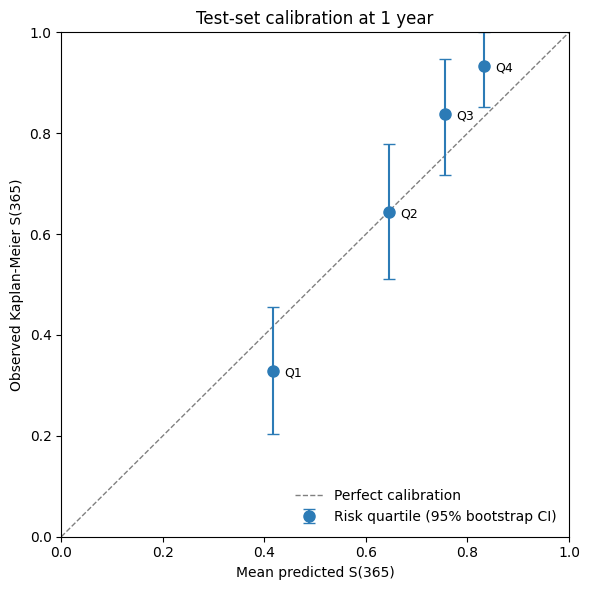

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=1, label="Perfect calibration")
ax.errorbar(
    calibration_by_quartile["pred_surv_365"],
    calibration_by_quartile["obs_km_surv_365"],
    yerr=[
        calibration_by_quartile["obs_km_surv_365"] - calibration_by_quartile["obs_ci_lo"],
        calibration_by_quartile["obs_ci_hi"] - calibration_by_quartile["obs_km_surv_365"],
    ],
    fmt="o",
    ms=8,
    capsize=4,
    c="#2c7bb6",
    label="Risk quartile (95% bootstrap CI)",
)
for _, r in calibration_by_quartile.iterrows():
    ax.annotate(
        str(r["risk_quartile"]).split(" ")[0],
        (r["pred_surv_365"], r["obs_km_surv_365"]),
        textcoords="offset points",
        xytext=(8, -4),
        fontsize=9,
    )
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted S(365)")
ax.set_ylabel("Observed Kaplan-Meier S(365)")
ax.set_title("Test-set calibration at 1 year")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
# fig


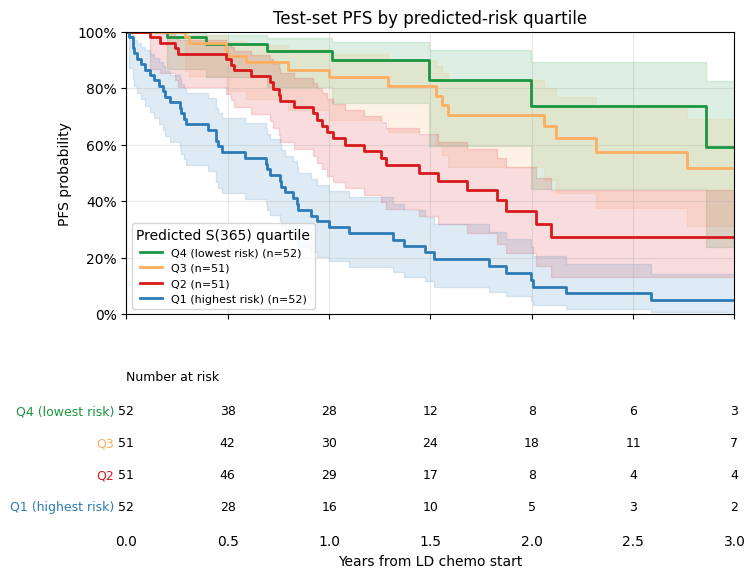

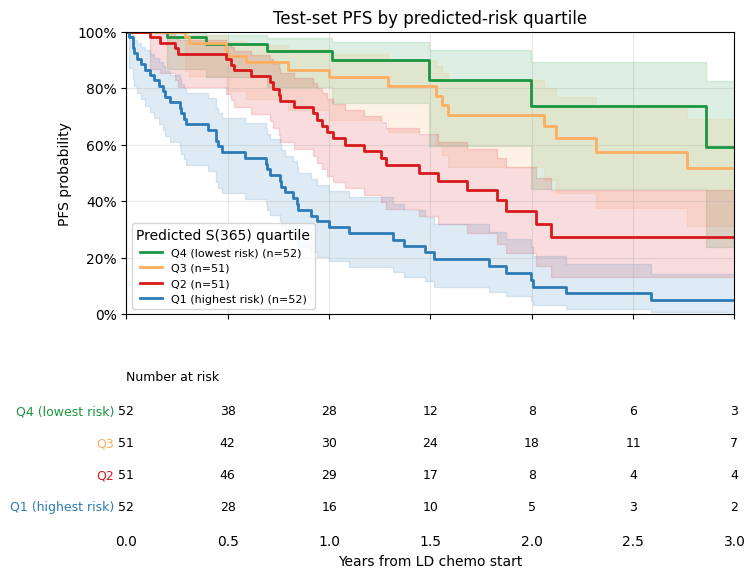

In [37]:
fig_km = km_plot_with_risktable(
    time=test_pred["pfs_days"].to_numpy(),
    event=test_pred["pfs_event_flag"].to_numpy(),
    group=test_pred["risk_quartile"].astype(str).to_numpy(),
    group_order=["Q4 (lowest risk)", "Q3", "Q2", "Q1 (highest risk)"],
    style=KMPlotStyle(
        time_divisor=365.25,
        xlabel="Years from LD chemo start",
        ylabel="PFS probability",
        title="Test-set PFS by predicted-risk quartile",
        legend_title="Predicted S(365) quartile",
        xlim=(0, 3),
        xticks=[0, 0.5, 1, 1.5, 2, 2.5, 3],
    ),
)
fig_km
